# Default of Credit Card Clients: Multivariate Analysis

All five analyses follow the same four sections and reach for the same tools. That repetition is deliberate: it shows the package covering very different data shapes with one workflow. The datasets differ underneath, and the notes below say where.

**This dataset.** 30000 rows and anonymised `X1..X23`. Figures render as static images rather than interactive ones, and Little's test is unusable at this size.

This notebook uses the datasets generated by `gen_multi.ipynb`. Run that notebook first if the CSV files in `data/` are missing.

In [1]:
import pandas as pd
import numpy as np

from missingfcup import MissingData
from missingfcup import Panel

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import plotly.io as pio
# Static images, unlike the other analyses. 30000 rows, and one interactive
# matrix serialises to ~14.5 MB of JSON; three of them plus the rest of the
# notebook would not fit in a usable file or a usable web page.
pio.renderers.default = "png"

In [2]:
df_mcar = pd.read_csv("data/mcar_multi.csv")
df_mar  = pd.read_csv("data/mar_multi.csv")
df_mnar = pd.read_csv("data/mnar_multi.csv")

In [3]:
md_mcar = MissingData(df_mcar)
md_mar  = MissingData(df_mar.drop(columns=["target"], errors="ignore"))
md_mnar = MissingData(df_mnar.drop(columns=["target"], errors="ignore"))

## Exploratory Discovery

These first plots validate that each generator introduced missingness at the expected scale.

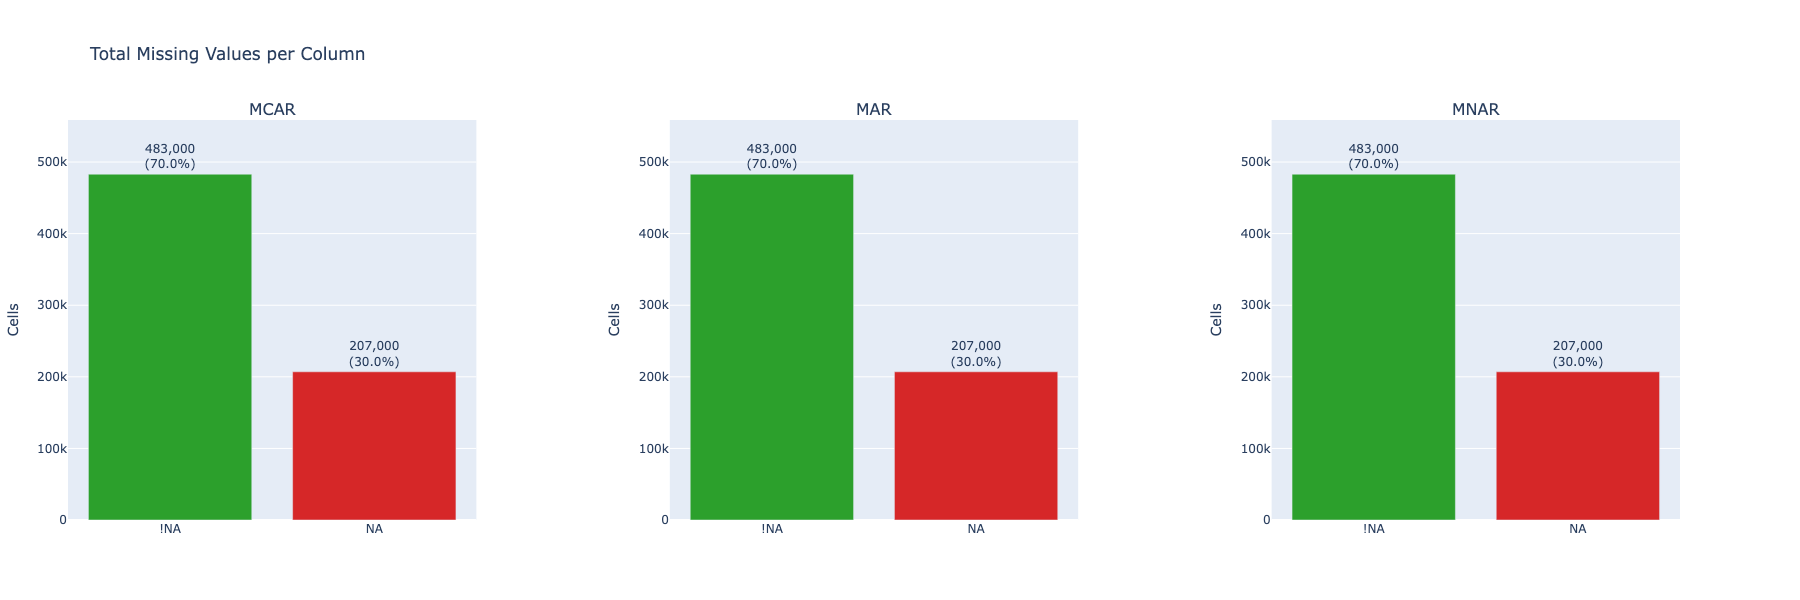

In [4]:
panel = Panel(
    plots=[
        md_mcar.totals(title="MCAR"),
        md_mar.totals(title="MAR"),
        md_mnar.totals(title="MNAR"),
    ],
    title="Total Missing Values per Column",
    width=1800,
    height=600,
)

panel.show()
panel.save()

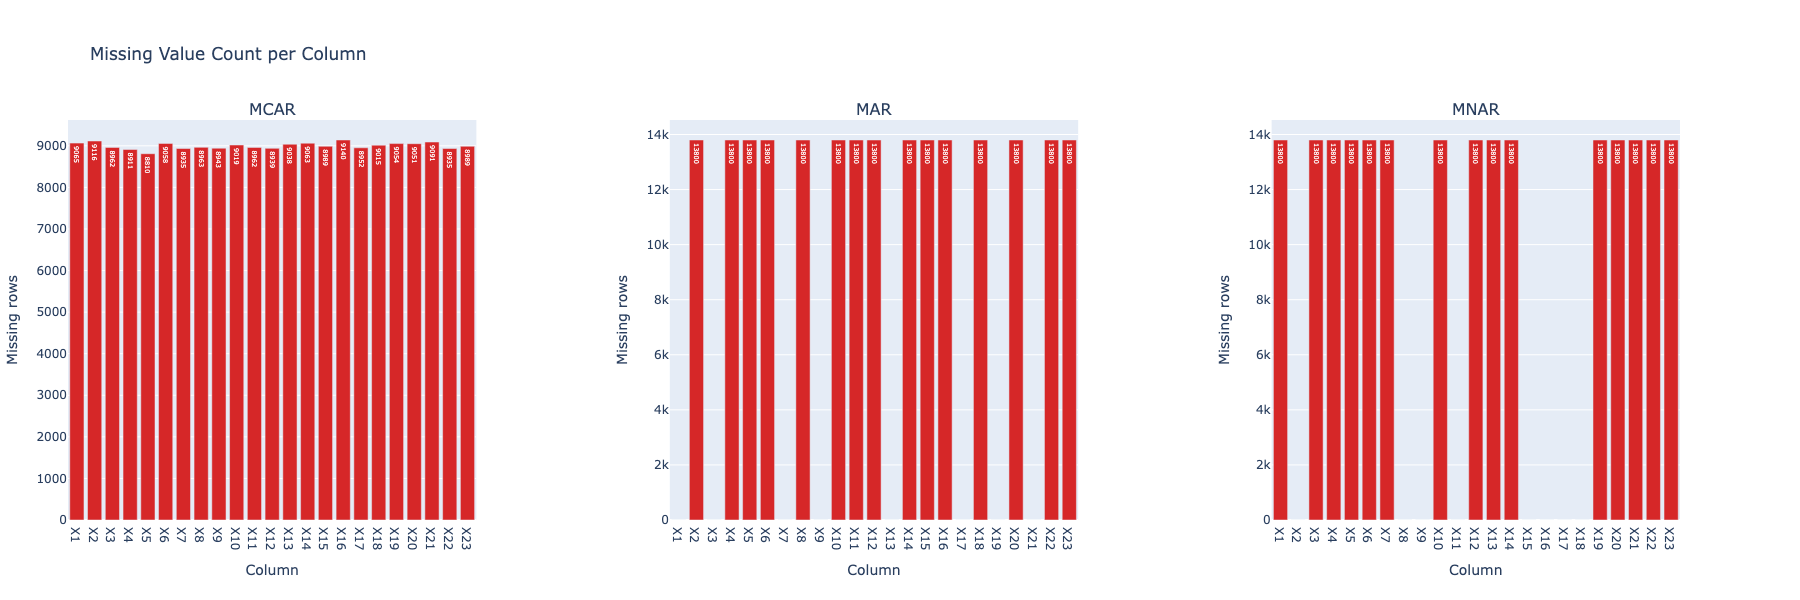

In [5]:
panel = Panel(
    plots=[
        md_mcar.bar(title="MCAR"),
        md_mar.bar(title="MAR"),
        md_mnar.bar(title="MNAR"),
    ],
    title="Missing Value Count per Column",
    width=1800,
    height=600,
)

panel.show()
panel.save()

`bar()` counts missing cells by default. `measure="fraction"` divides by the row count instead, which is what makes columns comparable; `"percentage"` is the same number on a 0-100 scale.

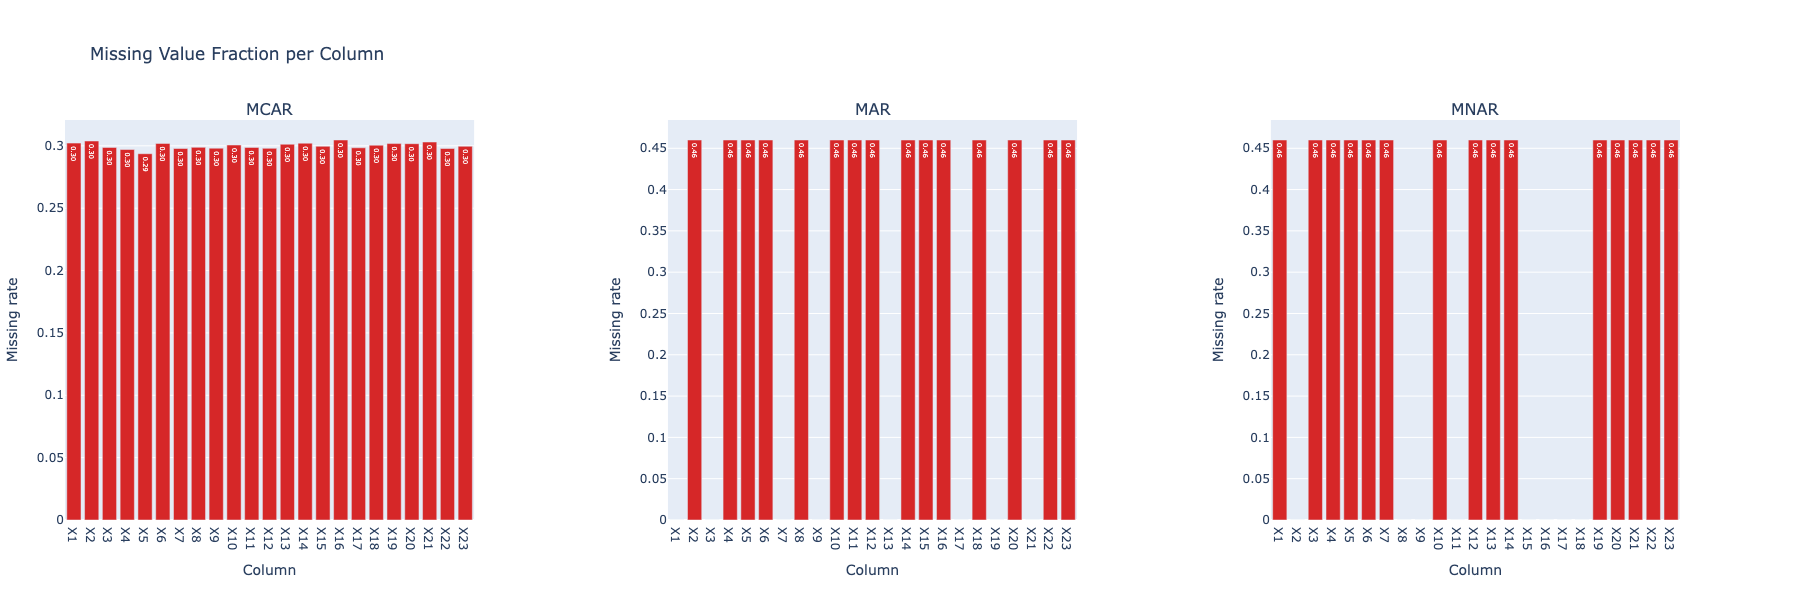

In [6]:
panel = Panel(
    plots=[
        md_mcar.bar(measure="fraction", title="MCAR"),
        md_mar.bar(measure="fraction", title="MAR"),
        md_mnar.bar(measure="fraction", title="MNAR"),
    ],
    title="Missing Value Fraction per Column",
    width=1800,
    height=600,
)

panel.show()
panel.save()

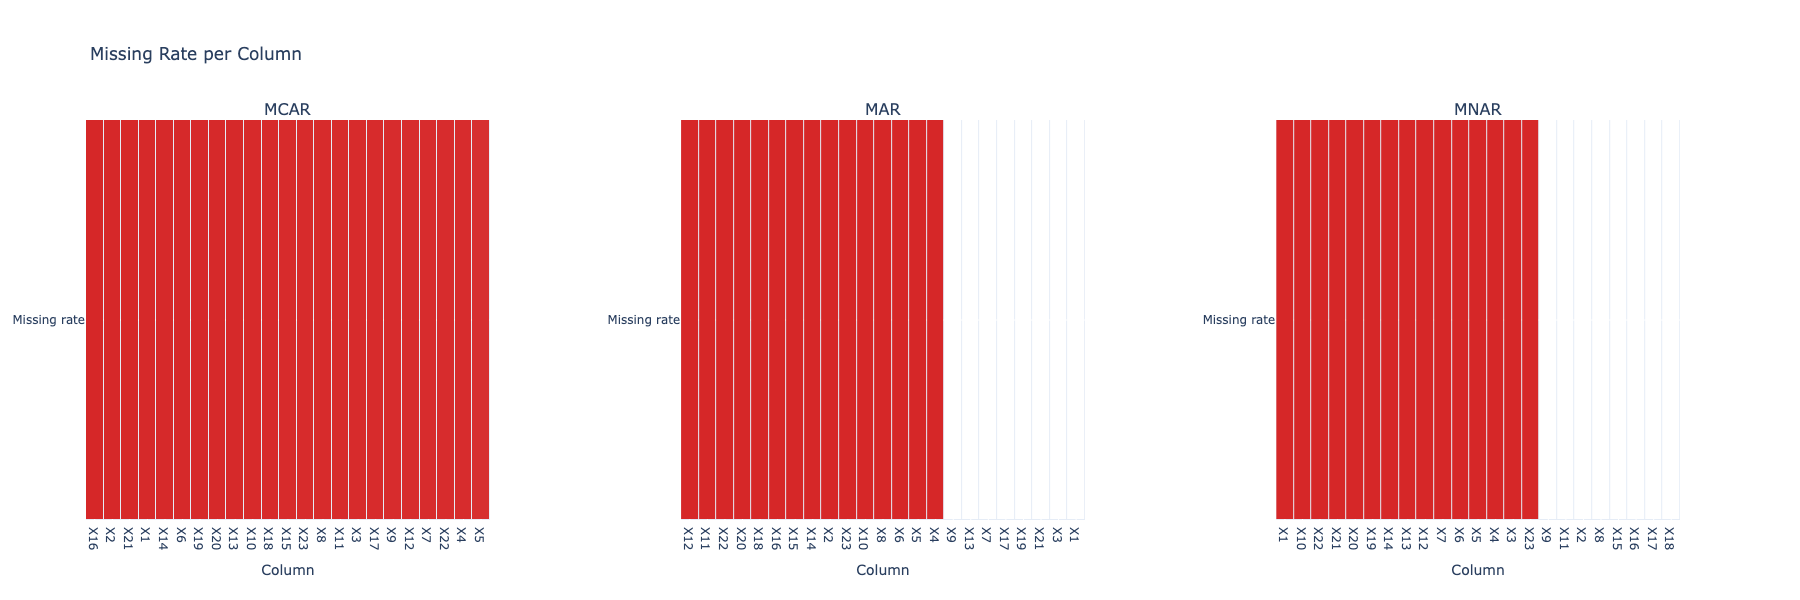

In [7]:
panel = Panel(
    plots=[
        md_mcar.rate(title="MCAR"),
        md_mar.rate(title="MAR"),
        md_mnar.rate(title="MNAR"),
    ],
    title="Missing Rate per Column",
    width=1800,
    height=600,
)

panel.show()
panel.save()

MCAR spreads missing values uniformly across all 23 columns (~30% each). MAR and MNAR both show a binary pattern: 15 columns have exactly 13800 missing values (~46%) while the remaining 8 have none.

The intersection and venn plots show which columns tend to be missing at the same time.

Every plot above is drawn from numbers the `MissingData` object already caches, and those numbers can be read directly. This is the same information the `totals`, `bar` and `rate` plots show, in the form you would use in a report or an assertion.

In [8]:
import pandas as pd

pd.DataFrame(
    {
        name: {
            "rows": obj.number_of_rows,
            "columns": obj.number_of_columns,
            "total missing rate": round(obj.total_missing_rate, 4),
            "complete rows": len(obj.rows_complete),
            "columns with gaps": int((obj.col_missing_rate > 0).sum()),
            "worst column rate": round(obj.col_missing_rate.max(), 4),
        }
        for name, obj in (("MCAR", md_mcar), ("MAR", md_mar), ("MNAR", md_mnar))
    }
).T

,rows,columns,total missing rate,complete rows,columns with gaps,worst column rate
MCAR,30000.0,23.0,0.3,7.0,23.0,0.3047
MAR,30000.0,23.0,0.3,11.0,15.0,0.4600
MNAR,30000.0,23.0,0.3,167.0,15.0,0.4600


All three datasets carry the same overall missing rate by construction (0.300, 0.300 and 0.300), so any difference between them later in the notebook comes from *where* the gaps fall, never from how many there are. The complete-row counts already hint at the difference: 7, 11 and 167 rows survive untouched out of 30000.

/Users/matias/Developer/thesis/missingfcup/src/missingfcup/plots/_upset.py:118: UserWarning: 63 missingness intersections found across 6 columns; drawing the 20 largest. Pass fewer columns in selected_columns to see all of them.
  intersection_counts = self._compute_intersections(cols)


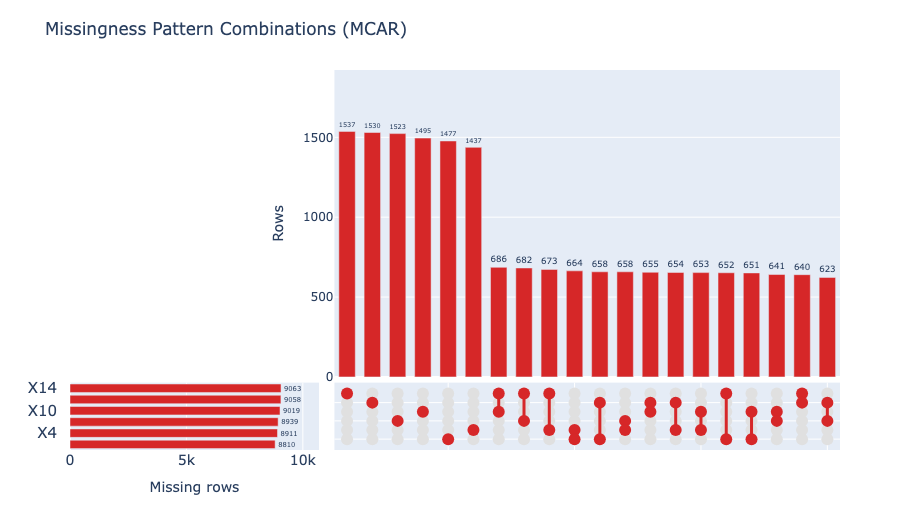

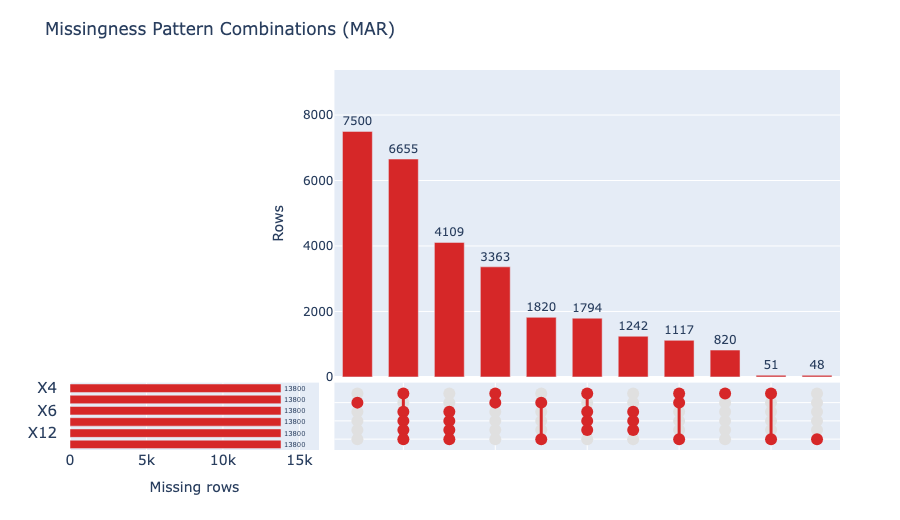

/Users/matias/Developer/thesis/missingfcup/src/missingfcup/plots/_upset.py:118: UserWarning: 63 missingness intersections found across 6 columns; drawing the 20 largest. Pass fewer columns in selected_columns to see all of them.
  intersection_counts = self._compute_intersections(cols)


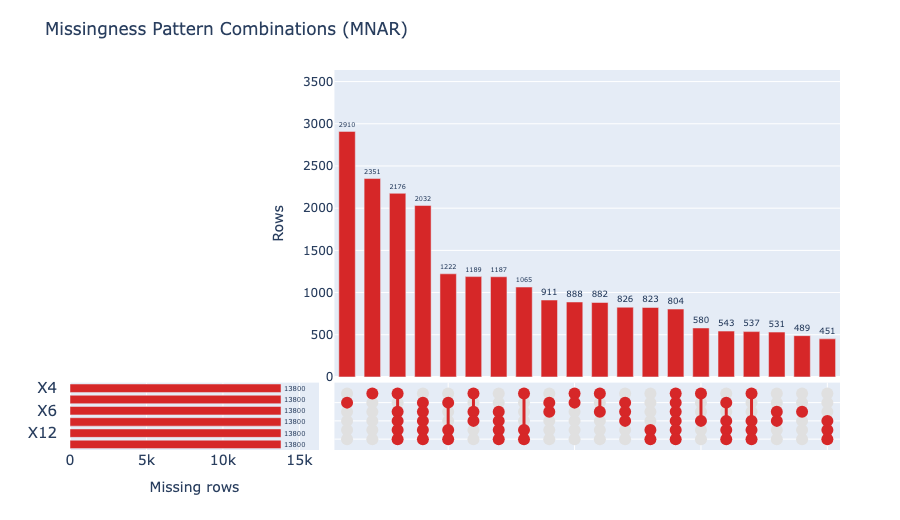

In [9]:
# upset() draws every column given, so columns are named, not picked
# automatically. These are the ones missing under all three mechanisms, keeping
# the three plots comparable. A warning about intersection count is itself
# diagnostic: MCAR scatters missingness into many distinct patterns, MAR and
# MNAR concentrate it into few.
upset_columns = [
    "X4",
    "X5",
    "X6",
    "X10",
    "X12",
    "X14",
]

plot_mcar = md_mcar.upset(selected_columns=upset_columns, title="Missingness Pattern Combinations (MCAR)")
plot_mar  = md_mar.upset(selected_columns=upset_columns, title="Missingness Pattern Combinations (MAR)")
plot_mnar = md_mnar.upset(selected_columns=upset_columns, title="Missingness Pattern Combinations (MNAR)")

plot_mcar.show()
plot_mcar.save()

plot_mar.show()
plot_mar.save()

plot_mnar.show()
plot_mnar.save()

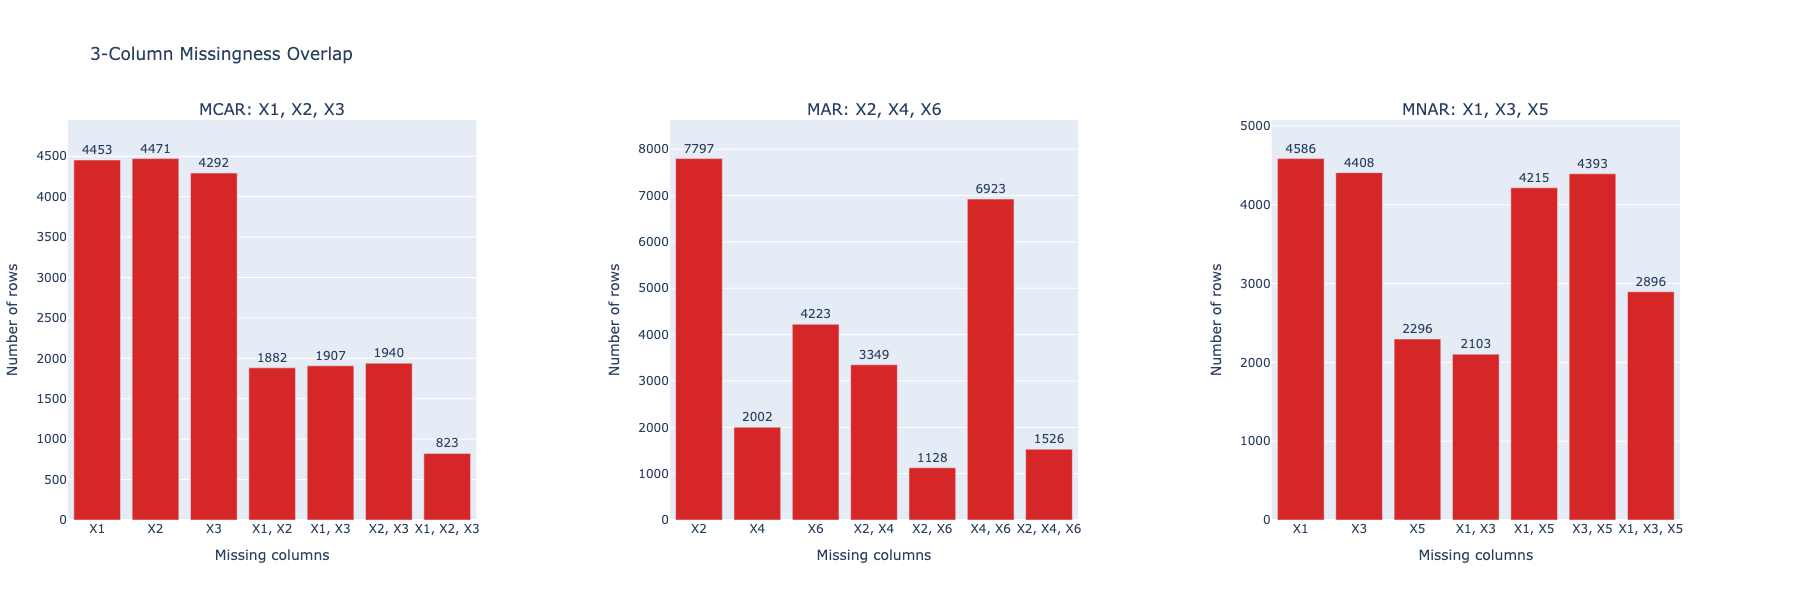

In [10]:
panel = Panel(
    plots=[
        md_mcar.venn(selected_columns=["X1", "X2", "X3"], title="MCAR: X1, X2, X3"),
        md_mar.venn(selected_columns=["X2", "X4", "X6"], title="MAR: X2, X4, X6"),
        md_mnar.venn(selected_columns=["X1", "X3", "X5"], title="MNAR: X1, X3, X5"),
    ],
    title="3-Column Missingness Overlap",
    width=1800,
    height=600,
)

panel.show()
panel.save()

## Mechanism Discovery

We now look for structural patterns in the missingness using heatmaps, correlation matrices, dendrograms, and value-missingness correlations.

A wide dataset does not read comfortably as one matrix. `max_columns` caps how many are drawn and keeps the ones with the most missingness, which is the usual first look before naming columns explicitly.

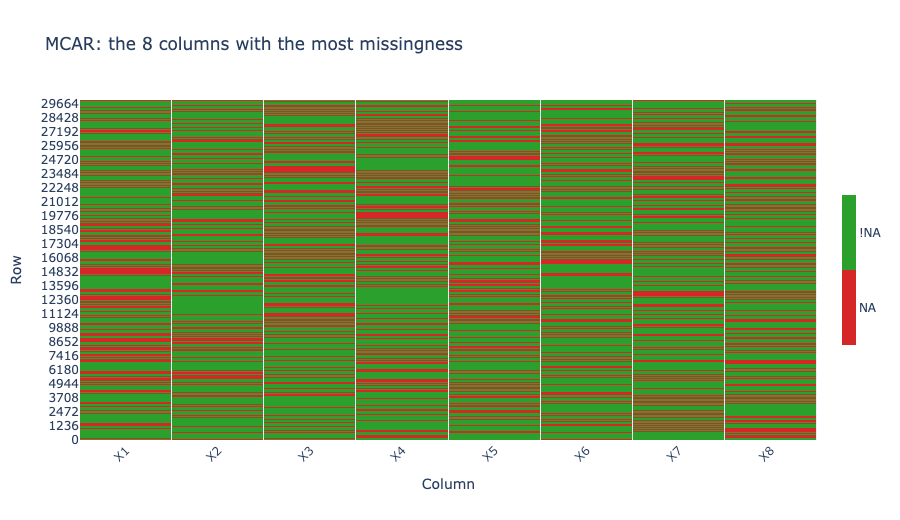

In [11]:
md_mcar.matrix(
    title="MCAR: the 8 columns with the most missingness",
    max_columns=8,
).show()

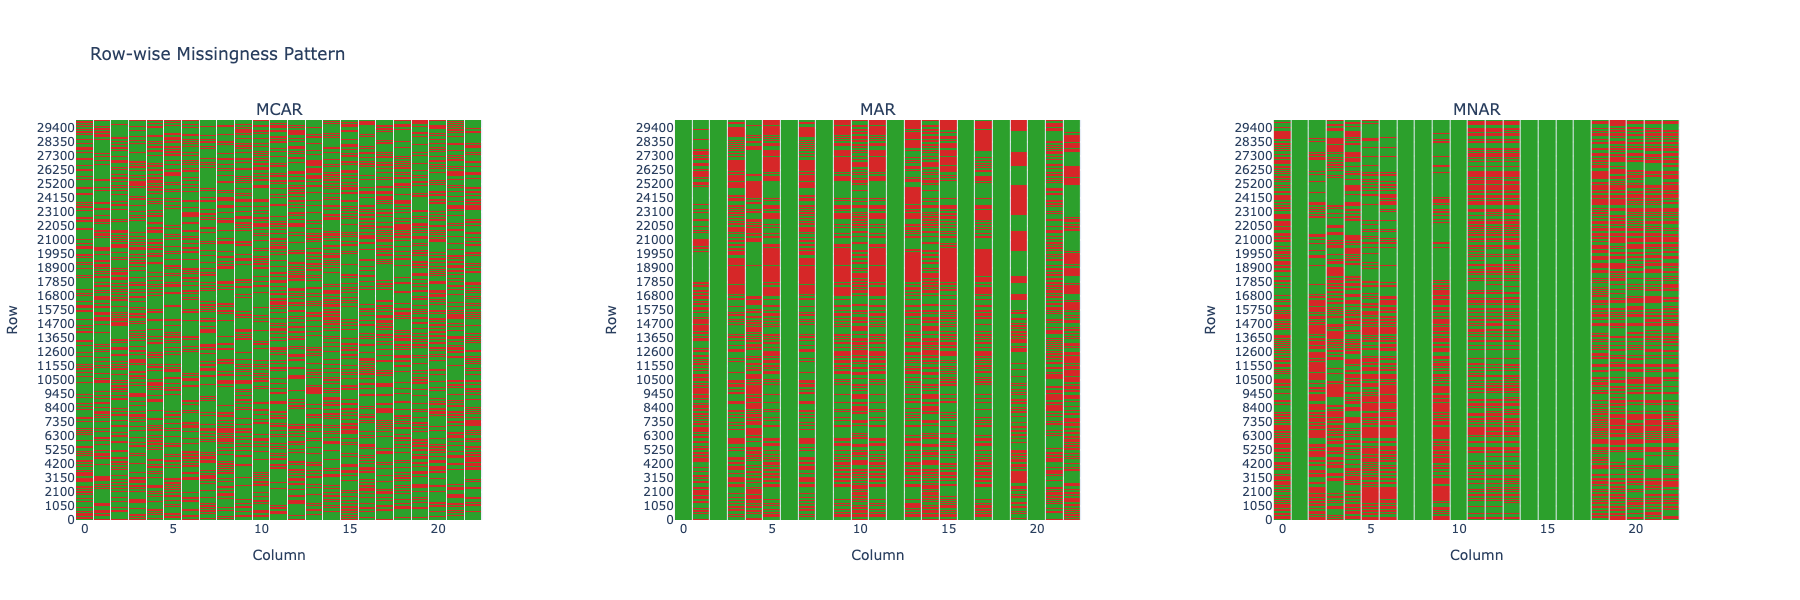

In [12]:
panel = Panel(
    plots=[
        md_mcar.matrix(title="MCAR"),
        md_mar.matrix(title="MAR"),
        md_mnar.matrix(title="MNAR"),
    ],
    title="Row-wise Missingness Pattern",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

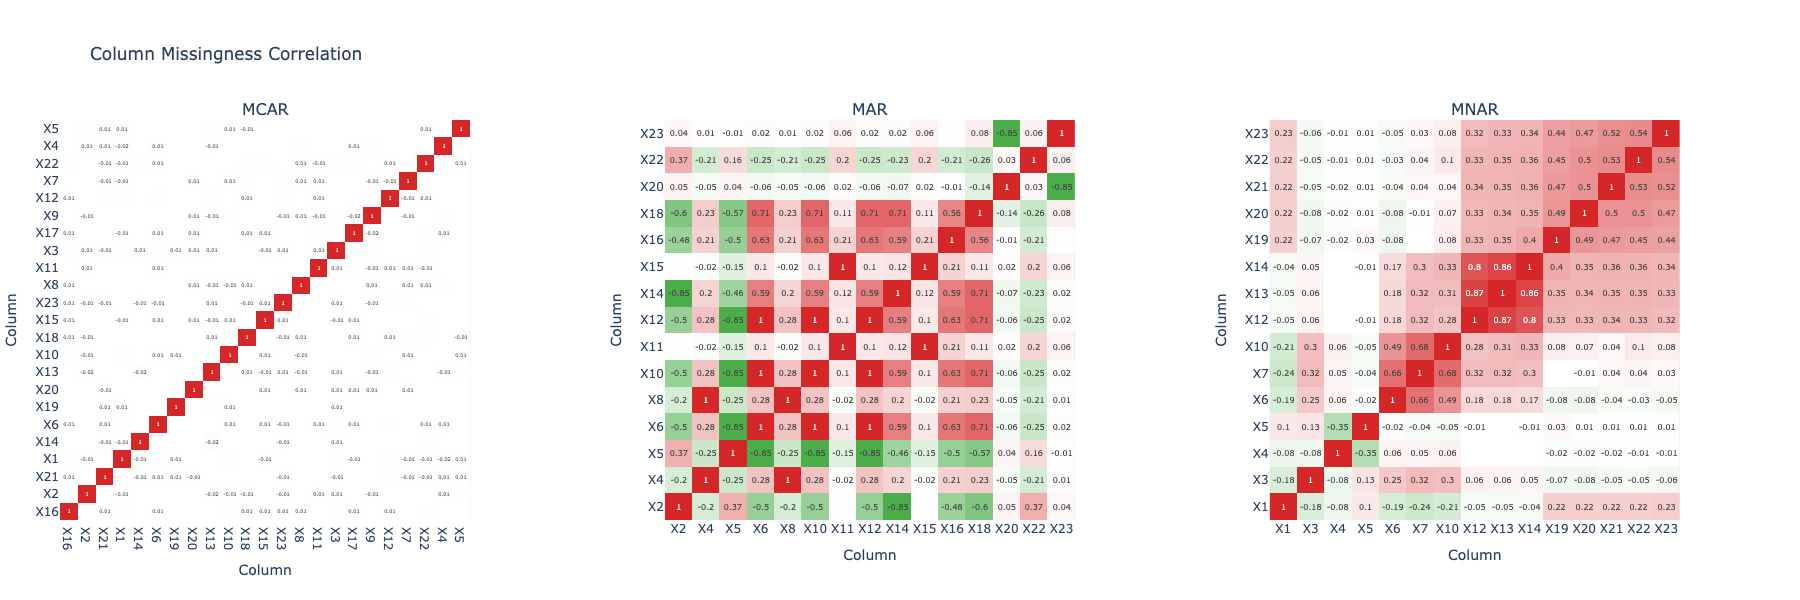

In [13]:
panel = Panel(
    plots=[
        md_mcar.heatmap(title="MCAR"),
        md_mar.heatmap(title="MAR", drop_constant_columns=True),
        md_mnar.heatmap(title="MNAR", drop_constant_columns=True),
    ],
    title="Column Missingness Correlation",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

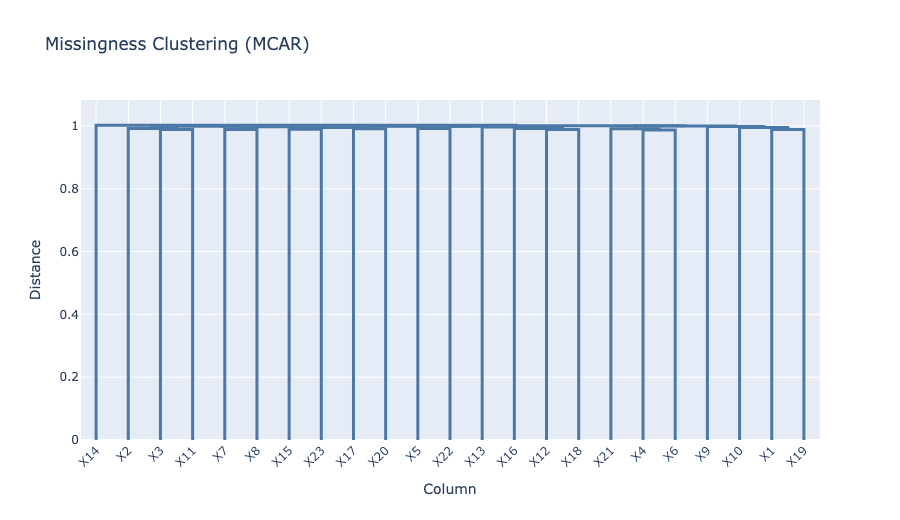

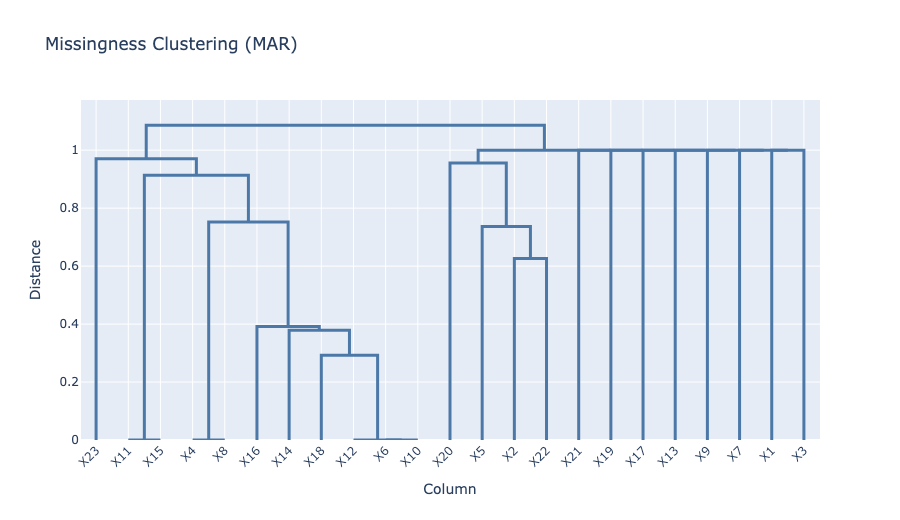

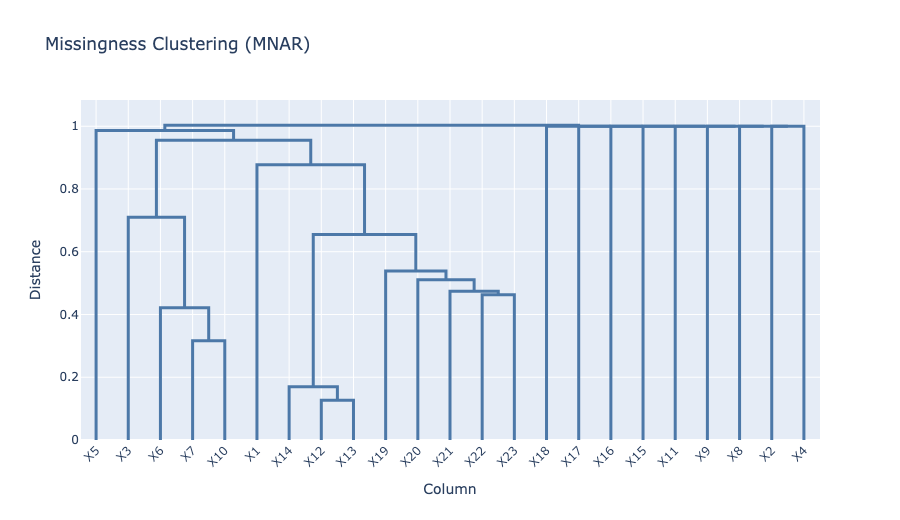

In [14]:
plot_mcar = md_mcar.dendrogram(title="Missingness Clustering (MCAR)")
plot_mar  = md_mar.dendrogram(title="Missingness Clustering (MAR)")
plot_mnar = md_mnar.dendrogram(title="Missingness Clustering (MNAR)")

plot_mcar.show()
plot_mcar.save()

plot_mar.show()
plot_mar.save()

plot_mnar.show()
plot_mnar.save()

The dendrogram argues visually that some columns go missing in the same rows. `perfectly_correlated_missing_columns()` settles it by returning the pairs whose missingness patterns are identical, and `missing_pattern_counts()` gives the row-side view: how many distinct patterns exist, and how common each one is.

In [15]:
for name, obj in (("MCAR", md_mcar), ("MAR", md_mar), ("MNAR", md_mnar)):
    pairs = obj.perfectly_correlated_missing_columns()
    patterns = obj.missing_pattern_counts()
    print(f"{name}: {len(pairs)} identical pairs, "
          f"{len(patterns)} distinct row patterns -> {pairs[:3]}")

MCAR: 0 identical pairs, 28699 distinct row patterns -> []


MAR: 5 identical pairs, 565 distinct row patterns -> [('X4', 'X8'), ('X6', 'X10'), ('X6', 'X12')]


MNAR: 0 identical pairs, 6112 distinct row patterns -> []


In [16]:
md_mar.missing_pattern_counts(max_patterns=5)

(X4, X6, X8, X10, X11, X12, X14, X15, X16, X18, X23)    1225
(X2, X5, X22, X23)                                      1079
(X2, X5, X11, X15, X20, X22)                            1058
(X4, X6, X8, X10, X11, X12, X14, X15, X16, X18, X20)     905
(X2, X5, X11, X15, X22, X23)                             890
Name: count, dtype: int64

Two numbers separate the mechanisms cleanly here.

MAR produces 5 pair(s) of columns whose gaps land on exactly the same rows, while MCAR and MNAR produce none. That follows from how the generators work: MAR selects rows using an observed driver, so a partner column's gaps coincide exactly with another's, whereas MNAR selects rows using each column's own values and produces overlapping but never identical patterns.

The pattern count says the same thing from the row side: 28699 distinct patterns under MCAR against 565 under MAR. Random deletion scatters rows into almost as many patterns as there are rows; a structured mechanism concentrates them into a few.

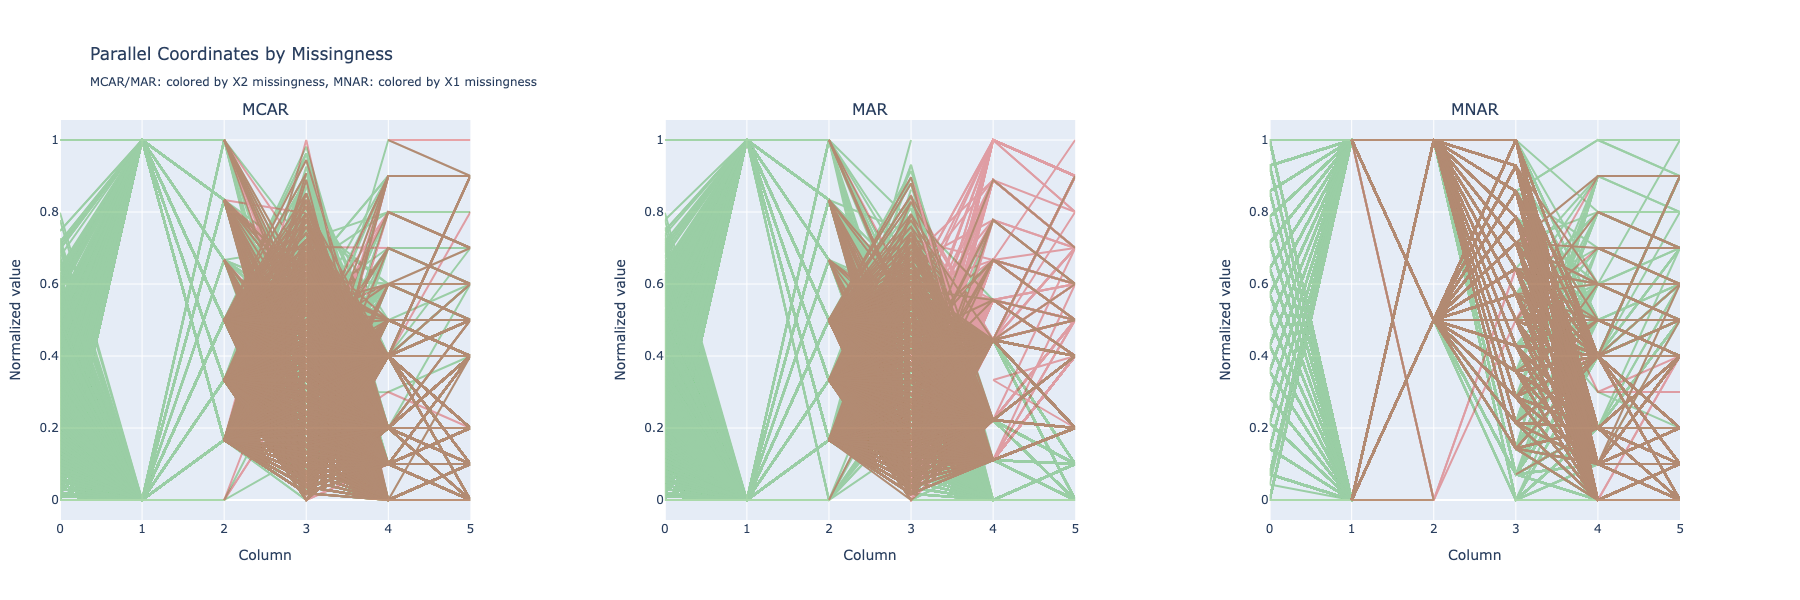

In [17]:
plot_mcar_pc = md_mcar.parallel_coordinates(
    title="MCAR",
    selected_columns=["X1", "X2", "X3", "X5", "X8", "X9"],
    missing_column="X2",
)
plot_mar_pc = md_mar.parallel_coordinates(
    title="MAR",
    selected_columns=["X1", "X2", "X3", "X5", "X8", "X9"],
    missing_column="X2",
)
plot_mnar_pc = md_mnar.parallel_coordinates(
    title="MNAR",
    selected_columns=["X1", "X2", "X3", "X5", "X8", "X9"],
    missing_column="X1",
)

panel = Panel(
    plots=[plot_mcar_pc, plot_mar_pc, plot_mnar_pc],
    title="Parallel Coordinates by Missingness",
    description="MCAR/MAR: colored by X2 missingness, MNAR: colored by X1 missingness",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

plot_mcar_pc.save()
plot_mar_pc.save()
plot_mnar_pc.save()

In MCAR, the X2-missing lines show no systematic deviation from X2-present lines across any of the six selected variables, confirming random deletion. In MAR, the X2-missing lines (affected partner column) concentrate at lower X1 values, consistent with credit-limit-based row selection by the MAR generator. In MNAR, the coloring switches to X1 missingness (an MNAR-affected column): the X1-missing lines cluster at lower X8 and X9 repayment-status values, an indirect signature that the non-defaulters (who settle payments promptly) were preferentially removed by the unobserved default indicator.

The same plot has a second mode. `kind="missingness"` plots the indicators rather than the values. At 30000 rows the lines overplot heavily, so read it for the dominant bands, not for individual rows.

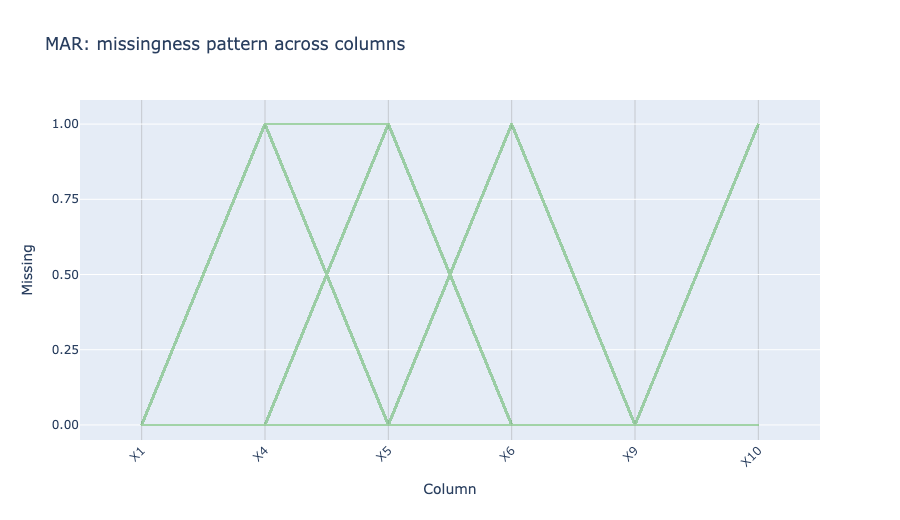

In [18]:
md_mar.parallel_coordinates(
    kind="missingness",
    selected_columns=["X1", "X4", "X5", "X6", "X9", "X10"],
    title="MAR: missingness pattern across columns",
).show()

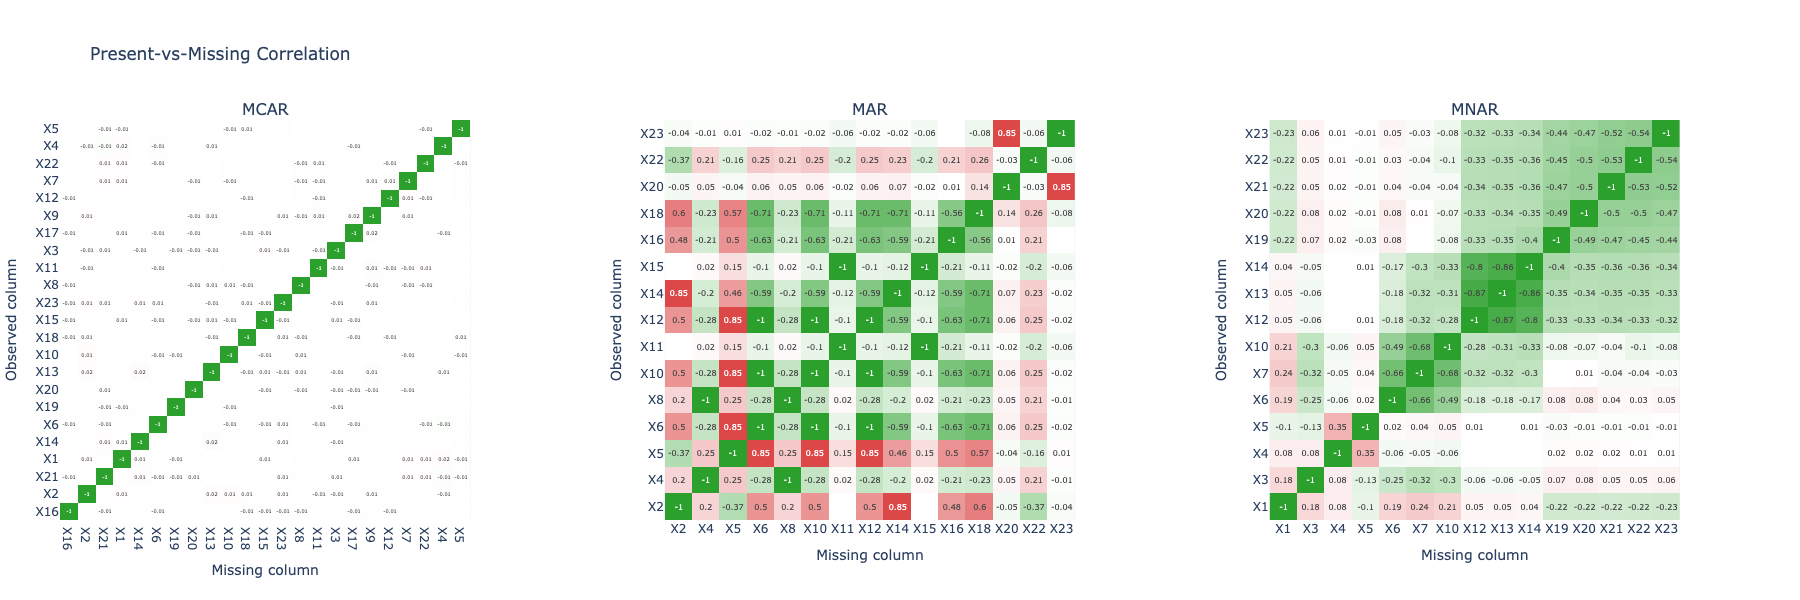

In [19]:
panel = Panel(
    plots=[
        md_mcar.heatmap(kind="predictive", title="MCAR"),
        md_mar.heatmap(kind="predictive", title="MAR", drop_constant_columns=True),
        md_mnar.heatmap(kind="predictive", title="MNAR", drop_constant_columns=True),
    ],
    title="Present-vs-Missing Correlation",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

The predictive heatmap reads indicators only. The biserial kind reads *values*. The column names here are anonymous, so this grid is the fastest way to find which `X` drives which without knowing what any of them mean.

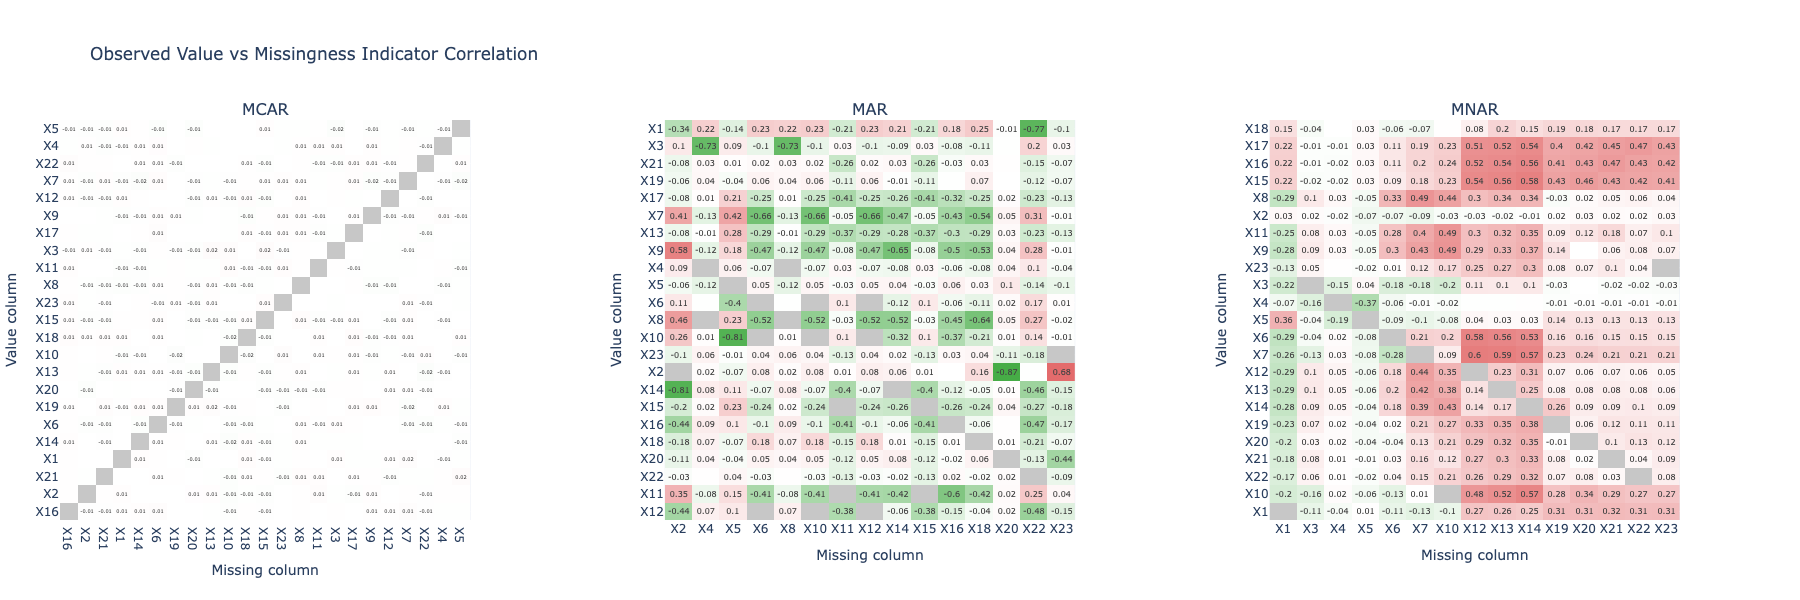

In [20]:
panel = Panel(
    plots=[
        md_mcar.heatmap(kind="biserial", title="MCAR", drop_constant_columns=True),
        md_mar.heatmap(kind="biserial", title="MAR", drop_constant_columns=True),
        md_mnar.heatmap(kind="biserial", title="MNAR", drop_constant_columns=True),
    ],
    title="Observed Value vs Missingness Indicator Correlation",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

* MCAR: the grid is flat. No column's values carry information about another column's gaps.

* MAR: the affected columns light up against their drivers, matching the driver-partner pairs the sorted matrices confirm below.

* MNAR: values and gaps are related here too, but the relation runs through each column's own removed values rather than a separate driver, which is why sorting by any observed column produces no block.

We now test three driver-partner candidate pairs identified from the predictive heatmap.
MAR drivers (non-affected columns): X1, X3, X7, X9, X13, X17, X19, X21.
MAR partners (affected columns): X2, X4, X5, X6, X8, X10, X11, X12, X14, X15, X16, X18, X20, X22, X23.

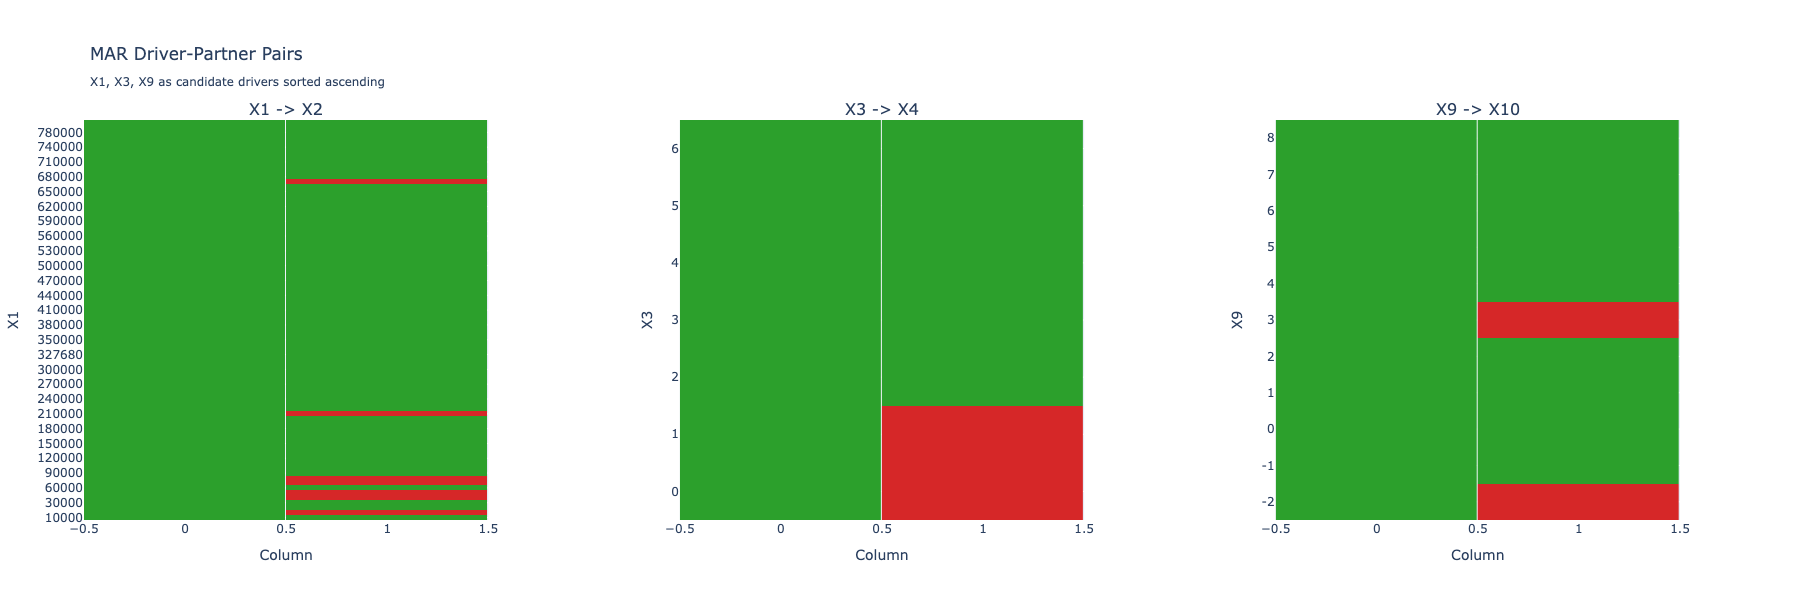

In [21]:
panel = Panel(
    plots=[
        md_mar.matrix(
            title="X1 -> X2",
            selected_columns=["X1", "X2"],
            sort_by="X1", ascending=True,
        ),
        md_mar.matrix(
            title="X3 -> X4",
            selected_columns=["X3", "X4"],
            sort_by="X3", ascending=True,
        ),
        md_mar.matrix(
            title="X9 -> X10",
            selected_columns=["X9", "X10"],
            sort_by="X9", ascending=True,
        ),
    ],
    title="MAR Driver-Partner Pairs",
    description="X1, X3, X9 as candidate drivers sorted ascending",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

For MNAR, the true driver is the unobserved target (default_payment_next_month). We sort by two non-affected proxy columns X8 and X9 (repayment status variables) that may correlate with the target.

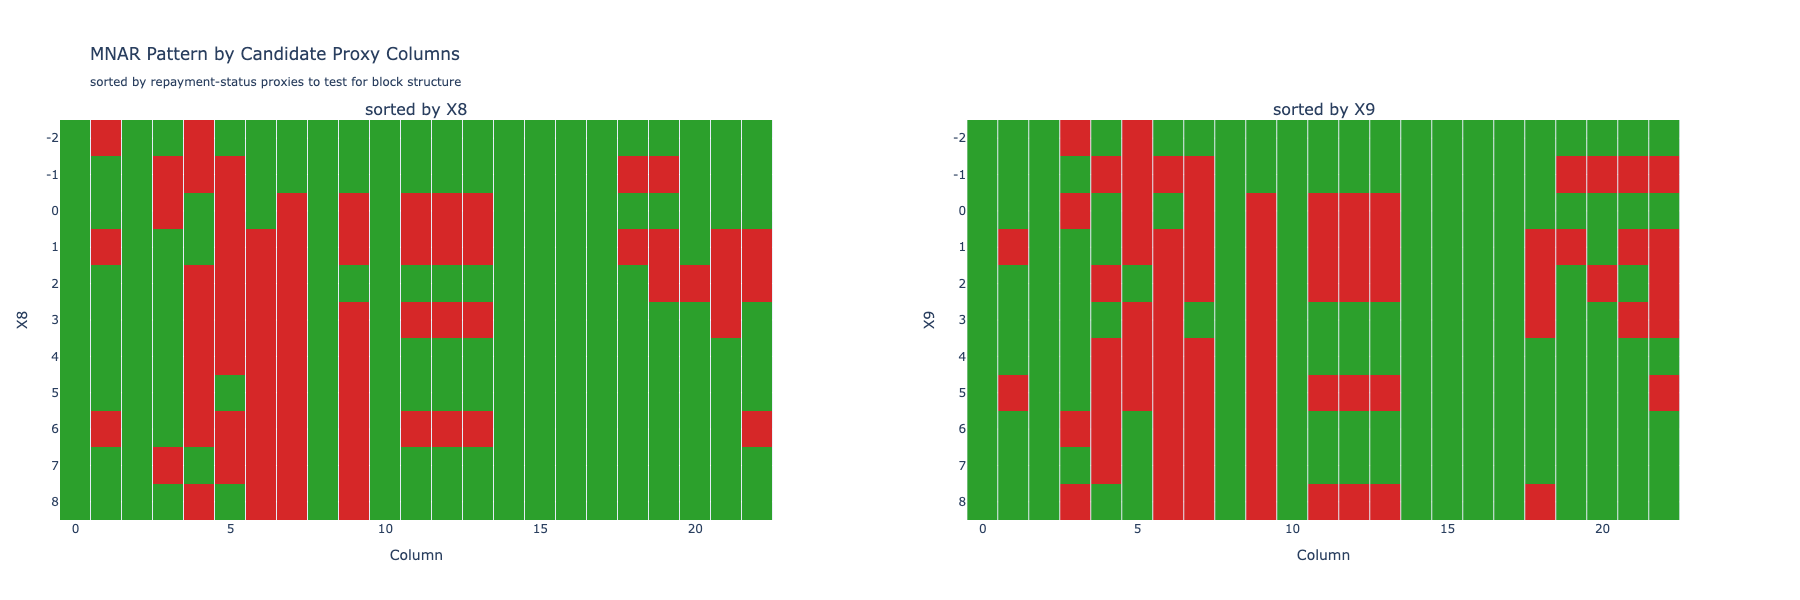

In [22]:
panel = Panel(
    plots=[
        md_mnar.matrix(
            title="sorted by X8",
            sort_by="X8", ascending=False
        ),
        md_mnar.matrix(
            title="sorted by X9",
            sort_by="X9", ascending=False
        ),
    ],
    title="MNAR Pattern by Candidate Proxy Columns",
    description="sorted by repayment-status proxies to test for block structure",
    width=1800,
    height=600,
)

panel.show()
panel.save(save_individual=True)

## Comparative Discovery

Since missingness was artificially introduced, the original complete dataset is available as ground truth. We use density plots, boxplots, and scatterplots to compare the distributions of observed values between present and missing groups.

To confirm MNAR, we compare observed distributions of proxy variables between MCAR and MNAR. MNAR removed rows where `default_payment_next_month=0` (non-defaulters, the lower-target-value group). Non-defaulters may differ in repayment behaviour (X8, X9) from defaulters, so their removal should produce a visible distribution shift.

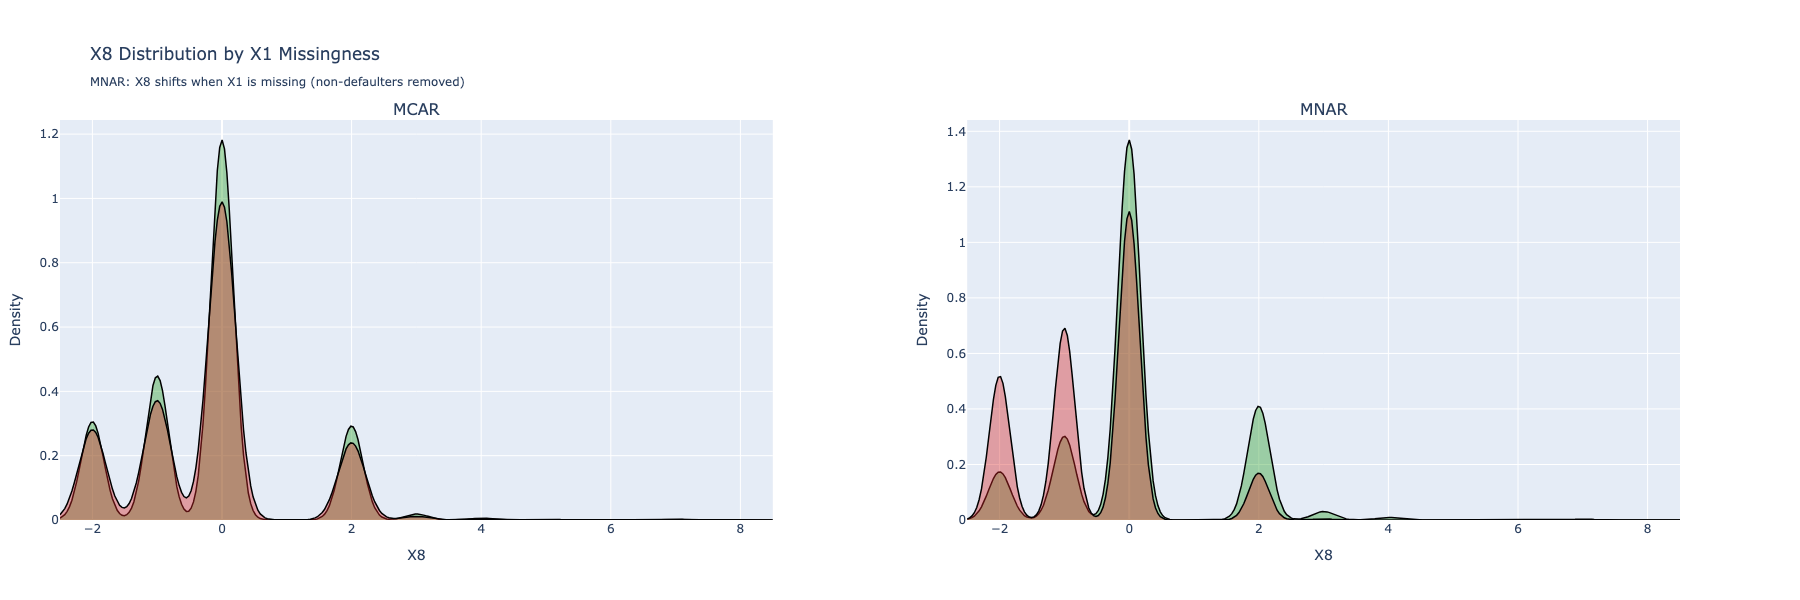

In [23]:
panel = Panel(
    plots=[
        md_mcar.density("X8", "X1", title="MCAR"),
        md_mnar.density("X8", "X1", title="MNAR"),
    ],
    title="X8 Distribution by X1 Missingness",
    description="MNAR: X8 shifts when X1 is missing (non-defaulters removed)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

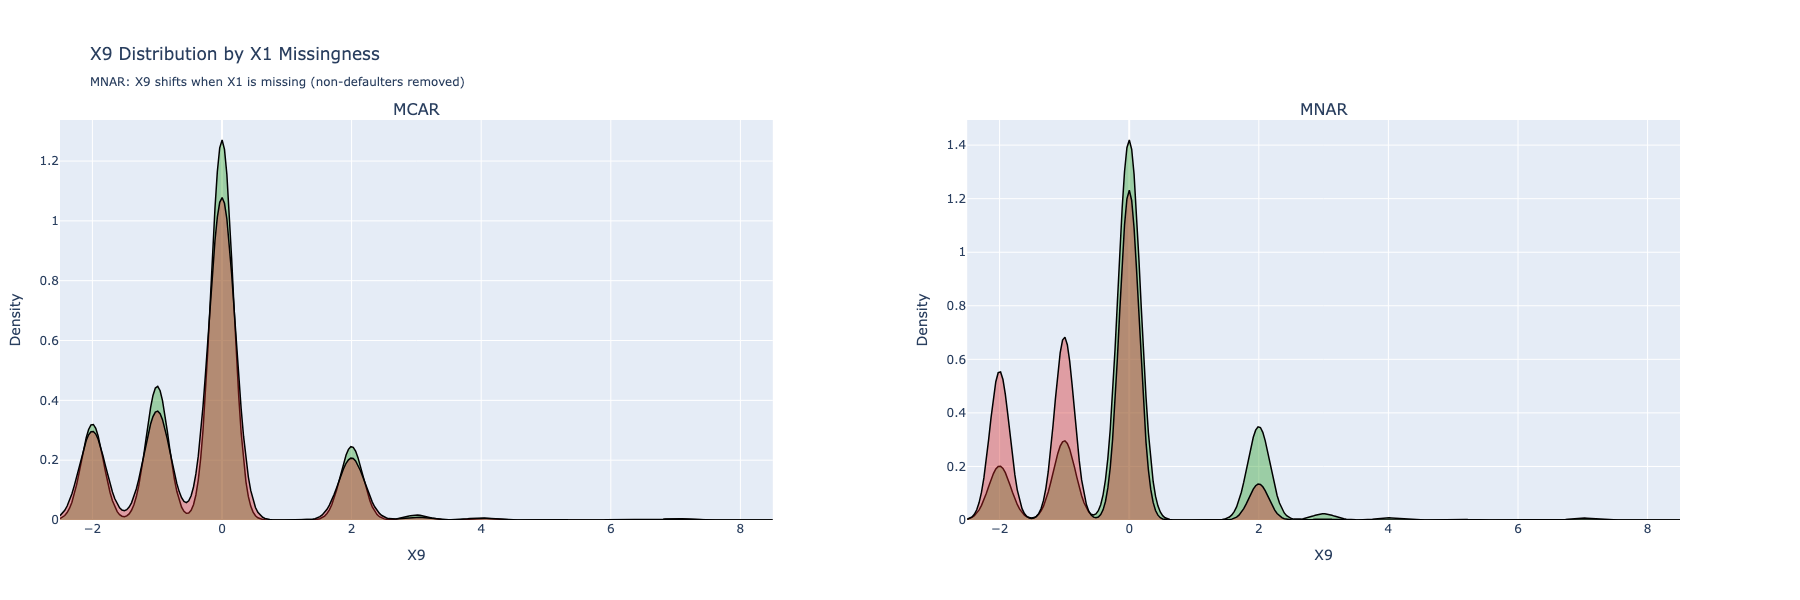

In [24]:
panel = Panel(
    plots=[
        md_mcar.density("X9", "X1", title="MCAR"),
        md_mnar.density("X9", "X1", title="MNAR"),
    ],
    title="X9 Distribution by X1 Missingness",
    description="MNAR: X9 shifts when X1 is missing (non-defaulters removed)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

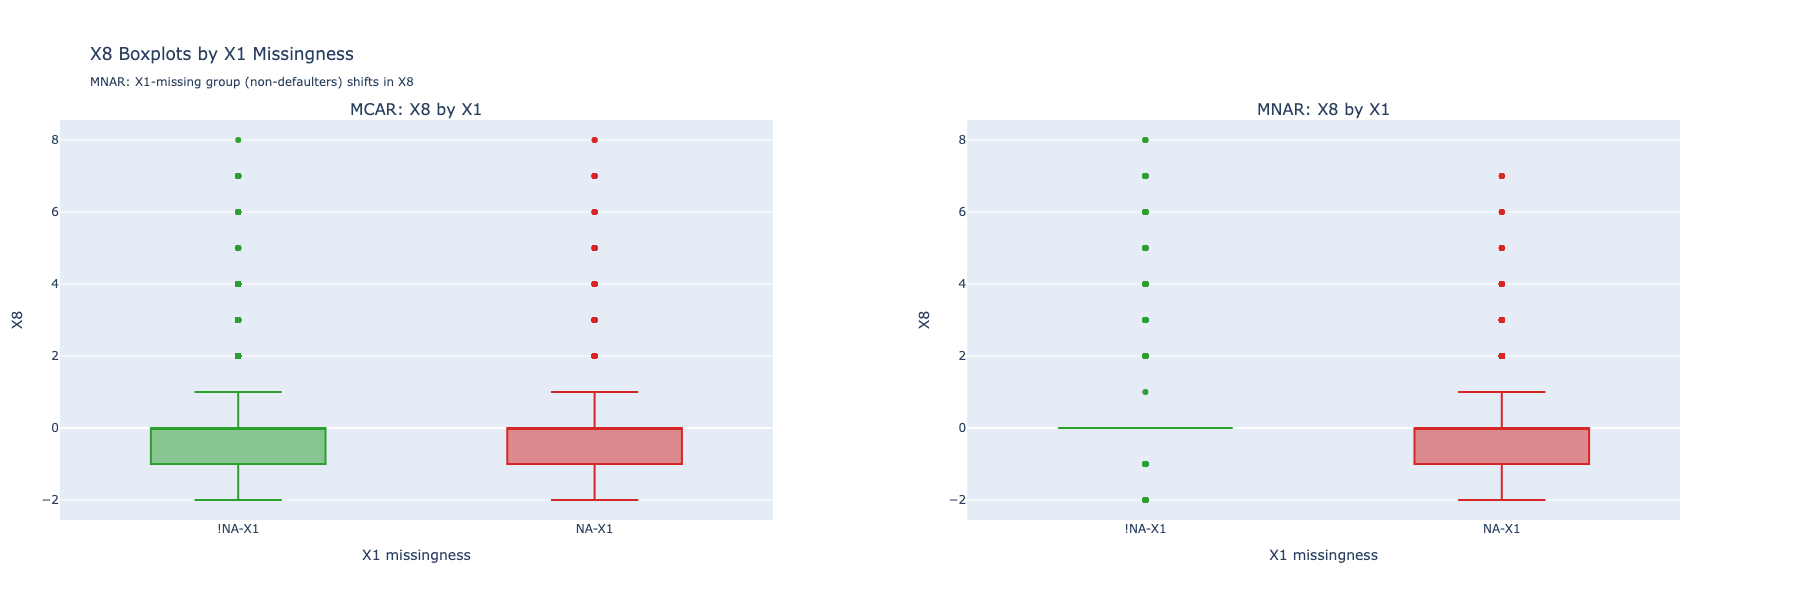

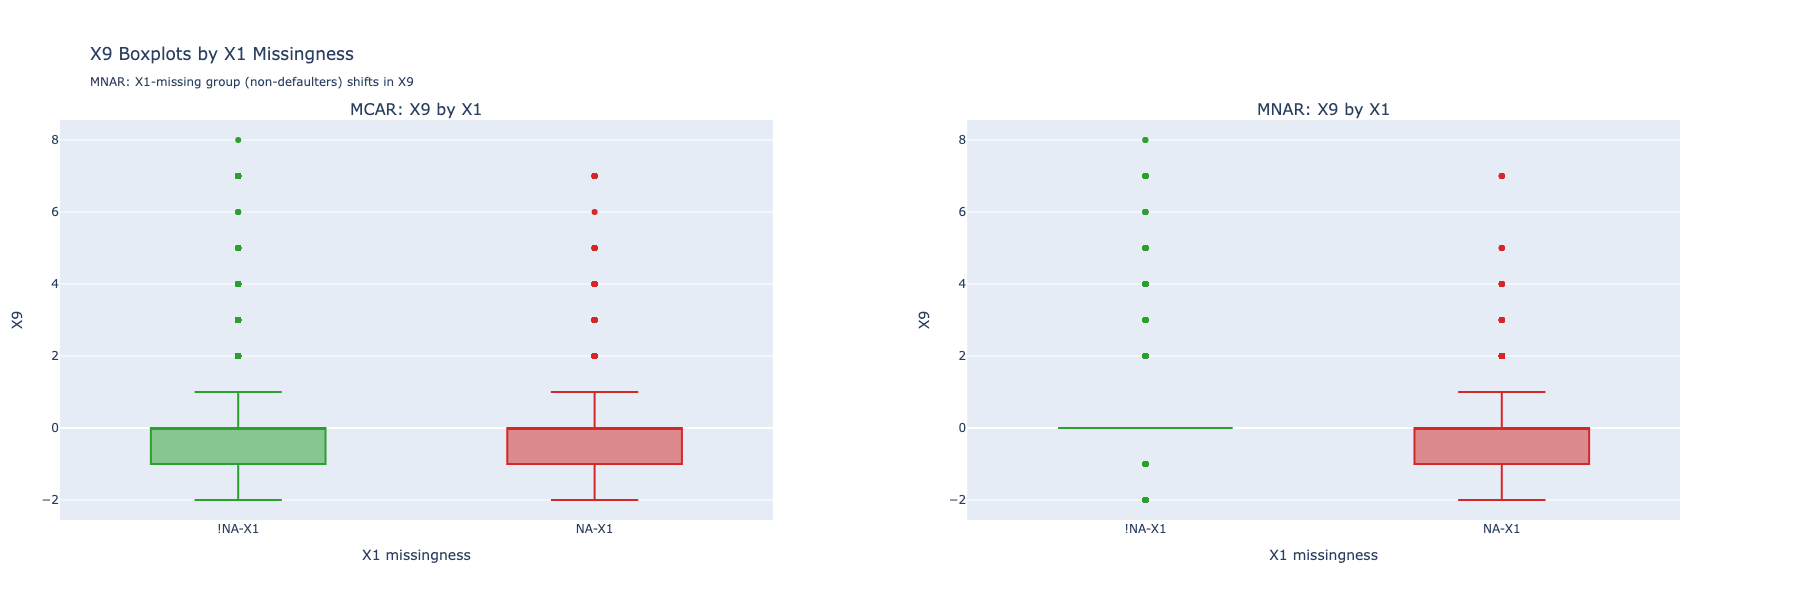

In [25]:
panel_x8 = Panel(
    plots=[
        md_mcar.boxplot("X8", "X1", title="MCAR: X8 by X1"),
        md_mnar.boxplot("X8", "X1", title="MNAR: X8 by X1"),
    ],
    title="X8 Boxplots by X1 Missingness",
    description="MNAR: X1-missing group (non-defaulters) shifts in X8",
    width=1800,
    height=600,
)

panel_x8.show()
panel_x8.save()

panel_x9 = Panel(
    plots=[
        md_mcar.boxplot("X9", "X1", title="MCAR: X9 by X1"),
        md_mnar.boxplot("X9", "X1", title="MNAR: X9 by X1"),
    ],
    title="X9 Boxplots by X1 Missingness",
    description="MNAR: X1-missing group (non-defaulters) shifts in X9",
    width=1800,
    height=600,
)

panel_x9.show()
panel_x9.save()

`boxplot` also draws violins. The repayment-status columns are discrete and pile up hard on a single value, so both groups report the same median. The violin separates them by shape where the box calls them identical.

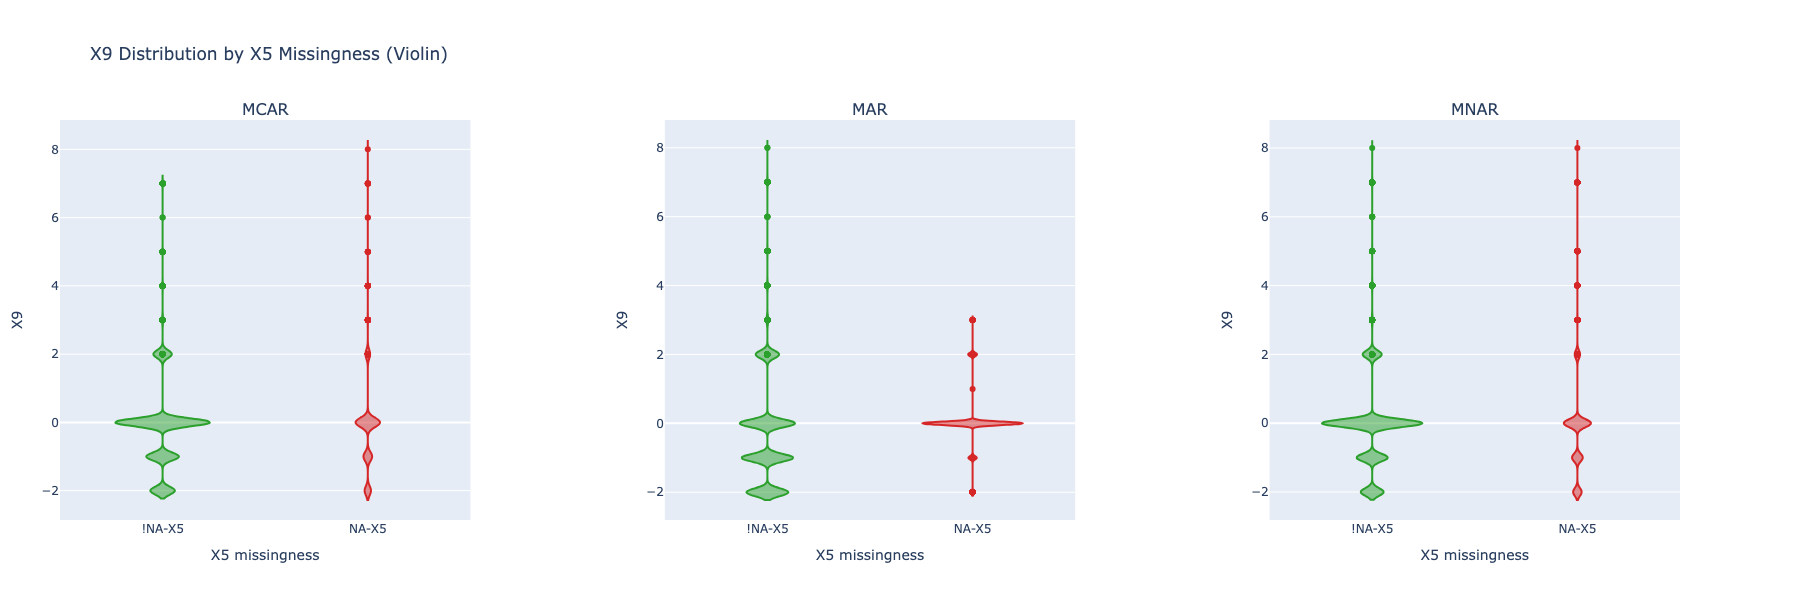

In [26]:
panel = Panel(
    plots=[
        md_mcar.boxplot("X9", "X5", kind="violin", title="MCAR"),
        md_mar.boxplot("X9", "X5", kind="violin", title="MAR"),
        md_mnar.boxplot("X9", "X5", kind="violin", title="MNAR"),
    ],
    title="X9 Distribution by X5 Missingness (Violin)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

Identical medians, different shape. On 30000 rows this is the difference between a test that fires and a plot that explains why.

We now apply boxplot, density, and scatterplot to compare all three mechanisms using X9 (MAR driver + MNAR non-affected proxy) and X5 (MAR partner + MNAR affected).

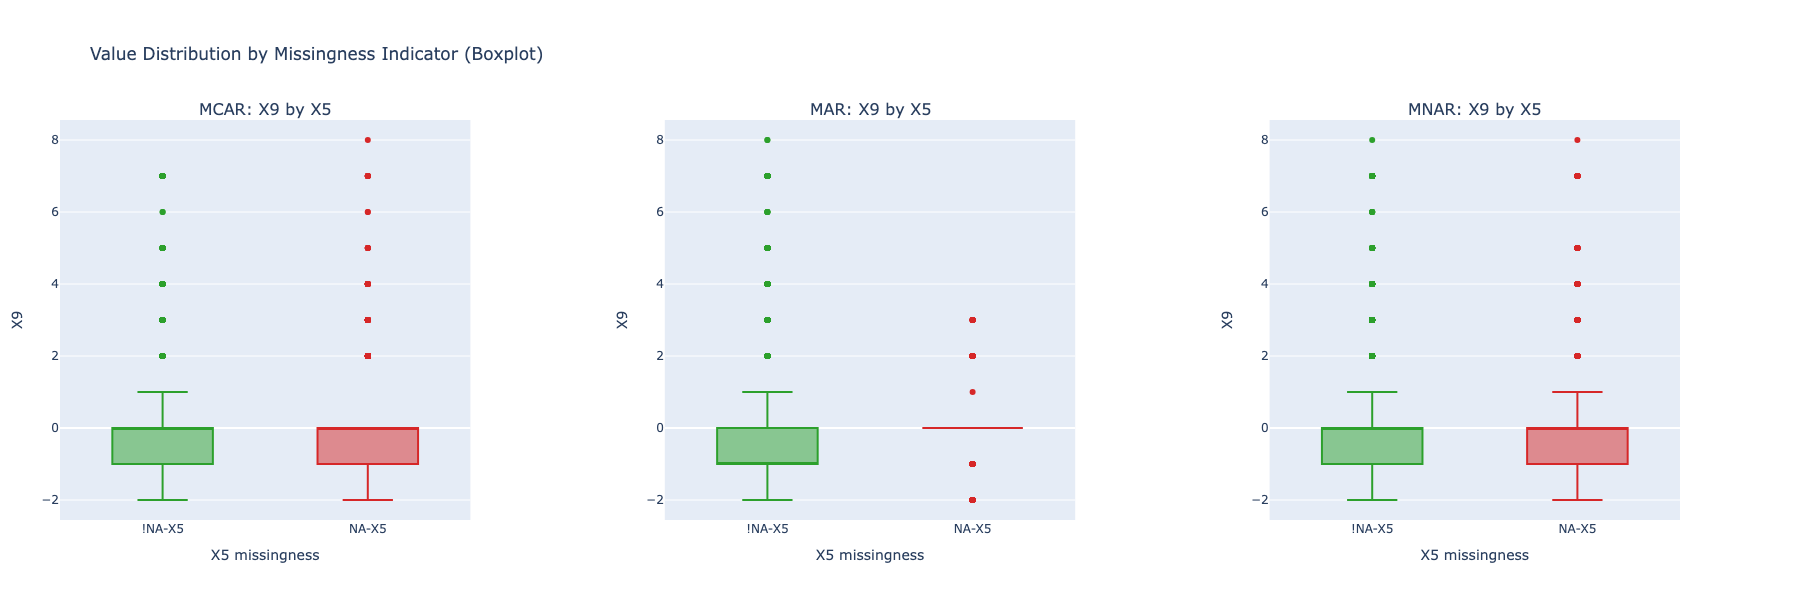

In [27]:
panel = Panel(
    plots=[
        md_mcar.boxplot("X9", "X5", title="MCAR: X9 by X5"),
        md_mar.boxplot("X9", "X5", title="MAR: X9 by X5"),
        md_mnar.boxplot("X9", "X5", title="MNAR: X9 by X5"),
    ],
    title="Value Distribution by Missingness Indicator (Boxplot)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

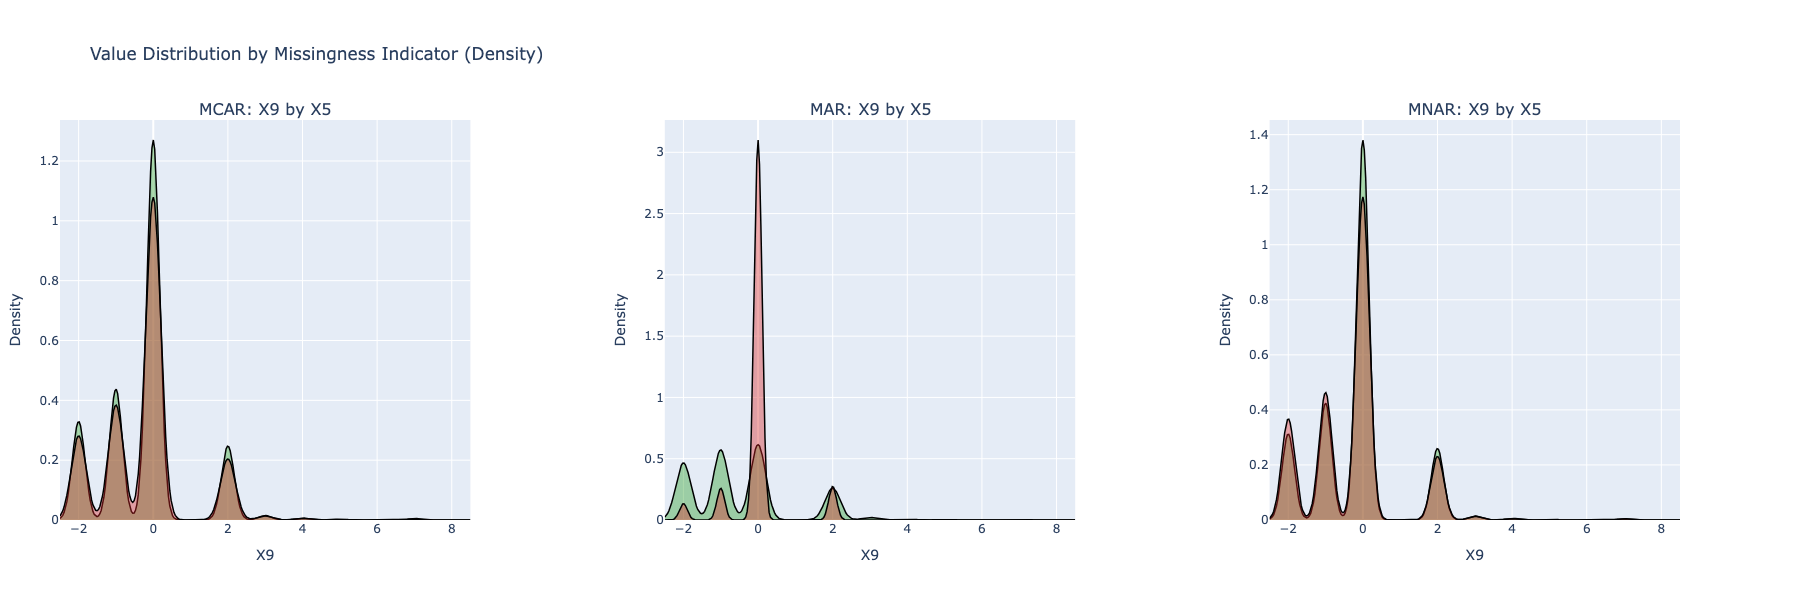

In [28]:
panel = Panel(
    plots=[
        md_mcar.density("X9", "X5", title="MCAR: X9 by X5"),
        md_mar.density("X9", "X5", title="MAR: X9 by X5"),
        md_mnar.density("X9", "X5", title="MNAR: X9 by X5"),
    ],
    title="Value Distribution by Missingness Indicator (Density)",
    width=1800,
    height=600,
)

panel.show()
panel.save()

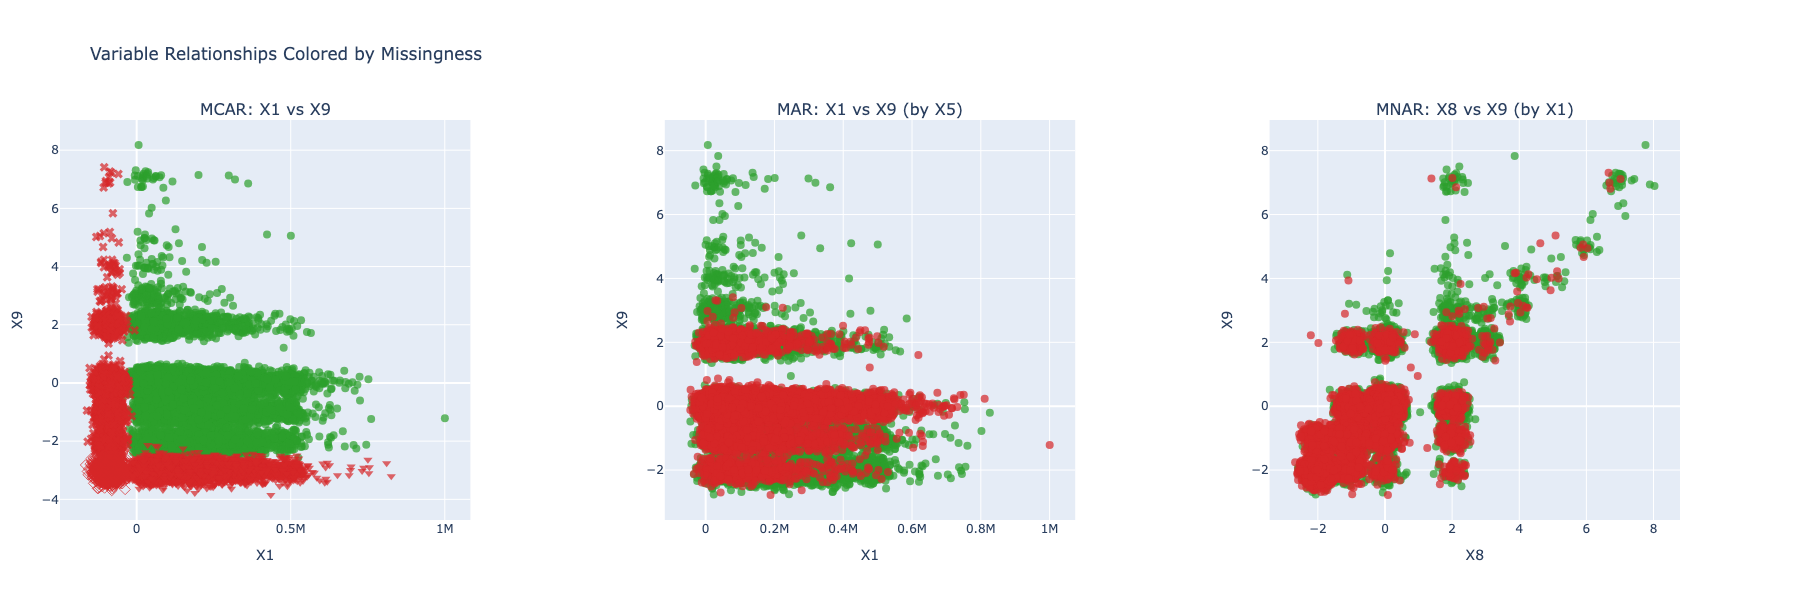

In [29]:
panel = Panel(
    plots=[
        md_mcar.scatterplot(x="X1", y="X9", title="MCAR: X1 vs X9"),
        md_mar.scatterplot(x="X1", y="X9", missing_column="X5", title="MAR: X1 vs X9 (by X5)"),
        md_mnar.scatterplot(x="X8", y="X9", missing_column="X1", title="MNAR: X8 vs X9 (by X1)"),
    ],
    title="Variable Relationships Colored by Missingness",
    width=1800,
    height=600,
)

panel.show()
panel.save()

## Statistical Tests

The plots carry the argument visually. These two tests put a number on it, and are worth reading for where they agree with the figures and where they do not.

Little's test asks whether the data is MCAR. A small p-value rejects MCAR; it does not say which of MAR or MNAR takes its place.

In [30]:
results = {
    "MCAR": md_mcar.littles_mcar_test(),
    "MAR":  md_mar.littles_mcar_test(),
    "MNAR": md_mnar.littles_mcar_test(),
}

pd.DataFrame({k: v[["chi2", "df", "p_value"]] for k, v in results.items()}).T

,chi2,df,p_value
MCAR,471861.900279,458238,0.0
MAR,117626.645002,9303,0.0
MNAR,222233.308498,97247,0.0


* MCAR: p=2.09e-45.
* MAR: p=0.
* MNAR: p=0.

The MCAR column rejects MCAR (p=2.09e-45) on data generated to be MCAR. With 30000 rows the test has enough power to flag deviations far too small to matter, which is the usual failure mode of a chi-square test on a large sample: statistical significance stops implying practical significance. The MAR and MNAR results (both p=0) are consistent with the plots, but the MCAR result means this test cannot be used on its own at this sample size.

The Mann-Whitney U test is the counterpart to `boxplot` and `density`: it asks whether the observed values of one column differ depending on whether another column is missing. We test `X4` against `X5` missingness.

In [31]:
tests = {
    "MCAR": md_mcar.mann_whitney_test(x="X4", by="X5"),
    "MAR":  md_mar.mann_whitney_test(x="X4", by="X5"),
    "MNAR": md_mnar.mann_whitney_test(x="X4", by="X5"),
}

pd.DataFrame(
    {k: v[["p_value", "significant", "median_present", "median_missing"]]
     for k, v in tests.items()}
).T

,p_value,significant,median_present,median_missing
MCAR,0.497923,False,2.0,2.0
MAR,0.0,True,1.0,2.0
MNAR,0.0,True,1.0,1.0


* MCAR: p=0.4979, not significant. The median `X4` is 2 in both groups. Whether `X5` is missing says nothing about `X4`.

* MAR: p=4.401e-16, with the median moving from 1 where `X5` is present to 2 where it is missing. This is the relationship the sorted matrices show as a block, now with a p-value.

* MNAR: p=0. A significant result here does not make `X5` a MAR predictor of `X4`. The MNAR generator removed values from `X4` and its neighbours directly, and that shifts any group comparison involving them. The test detects the shift; only the distribution plots show that its cause is the column's own removed values.

## Conclusions

* MCAR: missingness is spread uniformly across all 23 columns at roughly 30% each, and no column pair goes missing together systematically. The correlation heatmap, the dendrogram and the predictive heatmap all show near-zero structure, and the parallel coordinates show no separation between X2-missing and X2-present lines on any variable. MCAR confirmed.

* MAR: the generator paired 15 columns with an observed driver, and the data shows it. Exactly 15 columns carry 13800 missing values (~46%) while the remaining 8 carry none, the affected columns form a dense correlation cluster, and sorting the matrix by X1, X3 and X9 produces contiguous blocks in X2, X4 and X10 respectively. Missingness depends on observed values, not on the missing values themselves. MAR confirmed.

* MNAR: the same binary 15-vs-8 split appears, but no observed column explains it. Sorting by the repayment-status proxies X8 and X9 produces no block structure, which rules out MAR. The true driver is `default_payment_next_month`, which is the target and is absent from the feature matrix, so it can only be seen indirectly: the X1-missing lines cluster at lower X8 and X9 values, and the X8/X9 distributions shift between MCAR and MNAR. That shift is the signature of the non-defaulter cohort being removed by an unobserved variable. MNAR confirmed.

The anonymised `X1..X23` column names make this the hardest of the five datasets to read, which is exactly why the sorted matrix and the predictive heatmap carry the argument here: they work off structure rather than off domain knowledge of what each column means.

**What the metrics and tests add.** All three datasets carry the same 0.300 overall missing rate over 30000 rows. `perfectly_correlated_missing_columns()` returns 5 identical pairs under MAR and none under MCAR or MNAR, and the pattern count falls from 28699 distinct patterns under MCAR to 565 under MAR. The Mann-Whitney test on `X4` by `X5` missingness is flat for MCAR (p=0.4979) and significant for MAR (p=4.401e-16) and MNAR (p=0).

Little's test should not be used alone at this sample size. It rejects MCAR for the MCAR dataset (p=2.09e-45), which is the familiar behaviour of a chi-square statistic on 30000 rows: it has enough power to flag deviations far too small to matter, and statistical significance stops implying practical significance. The structural evidence above is what carries the conclusion.